# NEM demand from `NEMOSIS`

In [1]:
import pandas as pd
import glob

### Open demand data

"DISPATCHREGIONSUM" data, which are at 5-minute intervals.

In [72]:
data_path = "/g/data/w42/dr6273/tmp/"

In [73]:
files = sorted(glob.glob(data_path+"*DISPATCHREGIONSUM*.CSV"))
files[-3:]

['/g/data/w42/dr6273/tmp/PUBLIC_DVD_DISPATCHREGIONSUM_202310010000.CSV',
 '/g/data/w42/dr6273/tmp/PUBLIC_DVD_DISPATCHREGIONSUM_202311010000.CSV',
 '/g/data/w42/dr6273/tmp/PUBLIC_DVD_DISPATCHREGIONSUM_202312010000.CSV']

In [74]:
def open_df(path):
    return pd.read_csv(
        path,
        header=1,
        usecols=["REGIONID", "SETTLEMENTDATE", "TOTALDEMAND"],
        parse_dates=["SETTLEMENTDATE"],
        index_col="SETTLEMENTDATE",
    )

In [75]:
dfs = [open_df(f) for f in files]

In [76]:
df = pd.concat(dfs)

In [78]:
df

,REGIONID,TOTALDEMAND
SETTLEMENTDATE,,
2009-07-01 00:05:00,NSW1,8770.64
2009-07-01 00:05:00,QLD1,5219.07
2009-07-01 00:05:00,SA1,1591.33
2009-07-01 00:05:00,TAS1,933.98
2009-07-01 00:05:00,VIC1,5405.90
...,...,...
2024-01-01 00:00:00,QLD1,6294.38
2024-01-01 00:00:00,SA1,1296.67
2024-01-01 00:00:00,TAS1,1035.11


In [79]:
df.shape

(7908784, 2)

Remove NaNs

In [80]:
df.loc[df.REGIONID.isnull()].head()

,REGIONID,TOTALDEMAND
SETTLEMENTDATE,,
NaT,NaN,NaN
NaT,NaN,NaN
NaT,NaN,NaN
NaT,NaN,NaN
NaT,NaN,NaN


In [81]:
df = df.loc[~df.REGIONID.isnull()]

In [82]:
df

,REGIONID,TOTALDEMAND
SETTLEMENTDATE,,
2009-07-01 00:05:00,NSW1,8770.64
2009-07-01 00:05:00,QLD1,5219.07
2009-07-01 00:05:00,SA1,1591.33
2009-07-01 00:05:00,TAS1,933.98
2009-07-01 00:05:00,VIC1,5405.90
...,...,...
2024-01-01 00:00:00,NSW1,6587.63
2024-01-01 00:00:00,QLD1,6294.38
2024-01-01 00:00:00,SA1,1296.67


In [83]:
df.shape

(7908610, 2)

In [84]:
len(pd.date_range("2009-07-01 00:05:00", "2024-01-01 00:00:00", freq="5min")) * 5

7627680

Lengths don't match because we have some duplicate index values. Don't remove now as need to retain each region

In [85]:
len(pd.date_range("2009-07-01 00:05:00", "2024-01-01 00:00:00", freq="5min"))

1525536

In [86]:
len(pd.date_range("2009-07-01 00:05:00", "2024-01-01 00:00:00", freq="30min"))

254256

### Process each region separately

In [87]:
regions = pd.unique(df.REGIONID)
regions

array(['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1'], dtype=object)

In [98]:
dfs = []
for r in regions:
    rdf = df.loc[df.REGIONID == r]
    rdf = rdf.loc[~rdf.index.duplicated()]
    rdf = rdf.drop("REGIONID", axis=1)
    rdf.columns = [r]
    dfs.append(rdf)

In [99]:
dem = pd.concat(dfs, axis=1)
dem

,NSW1,QLD1,SA1,TAS1,VIC1
SETTLEMENTDATE,,,,,
2009-07-01 00:05:00,8770.64,5219.07,1591.33,933.98,5405.90
2009-07-01 00:10:00,8808.24,5271.33,1589.66,934.70,5368.79
2009-07-01 00:15:00,8823.20,5191.56,1609.87,929.88,5362.76
2009-07-01 00:20:00,8776.82,5154.33,1594.49,924.12,5311.96
2009-07-01 00:25:00,8725.02,5149.72,1582.01,921.72,5301.42
...,...,...,...,...,...
2023-12-31 23:40:00,6649.50,6384.64,1339.67,1052.62,4070.49
2023-12-31 23:45:00,6631.86,6374.79,1296.45,1058.23,4035.14
2023-12-31 23:50:00,6649.77,6386.35,1301.21,1055.42,4039.52


Convert from AEST to UTC to align with BARRA-C2

In [104]:
dem.index -= pd.DateOffset(hours=10)

The data are in MW. This is the output at any moment. We want to convert this to MWh. To convert these 5-minute ratings, we divide them by (60 / 5) = 12:

In [132]:
dem_mwh = dem / 12

Then we can sum by hour

In [137]:
dem_hourly = dem_mwh.resample("h").sum()

In [140]:
dem_hourly

,NSW1,QLD1,SA1,TAS1,VIC1
SETTLEMENTDATE,,,,,
2009-06-30 14:00:00,7945.377500,4679.339167,1438.372500,845.318333,4810.673333
2009-06-30 15:00:00,8285.597500,4746.761667,1343.127500,904.636667,5393.625833
2009-06-30 16:00:00,7586.278333,4505.274167,1182.105000,895.562500,5038.578333
2009-06-30 17:00:00,7039.883333,4434.766667,1048.341667,906.427500,4771.565833
2009-06-30 18:00:00,6915.753333,4525.978333,1046.805833,948.933333,4660.491667
...,...,...,...,...,...
2023-12-31 10:00:00,6864.406667,7405.500833,1325.327500,1086.835833,4104.092500
2023-12-31 11:00:00,6921.819167,7096.175833,1304.117500,1089.974167,3922.525000
2023-12-31 12:00:00,6836.492500,6791.627500,1265.759167,1088.391667,3834.623333


Remove first and last day as incomplete days

In [145]:
dem_hourly = dem_hourly.loc["2009-07-01" : "2023-12-30"]

In [146]:
dem_hourly

,NSW1,QLD1,SA1,TAS1,VIC1
SETTLEMENTDATE,,,,,
2009-07-01 00:00:00,9811.083333,6319.625000,1694.600833,1359.704167,6737.801667
2009-07-01 01:00:00,9518.105000,6201.692500,1715.465000,1293.429167,6679.405000
2009-07-01 02:00:00,9362.036667,6183.130833,1686.535833,1279.117500,6602.611667
2009-07-01 03:00:00,9228.744167,6156.053333,1695.395833,1265.324167,6730.846667
2009-07-01 04:00:00,9131.188333,6155.266667,1677.635833,1301.748333,6599.993333
...,...,...,...,...,...
2023-12-30 19:00:00,5894.277500,5485.632500,1123.896667,1014.753333,3378.028333
2023-12-30 20:00:00,6032.074167,5178.148333,1048.507500,1007.285000,3199.995833
2023-12-30 21:00:00,6182.783333,4890.277500,845.329167,1017.429167,2819.802500


Rename columns

In [147]:
dem_hourly.columns = ["NSW", "QLD", "SA", "TAS", "VIC"]

/jobfs/139471656.gadi-pbs/ipykernel_69473/2413363028.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dem_hourly.sum(axis=1).resample("M").sum().plot()


<AxesSubplot: xlabel='SETTLEMENTDATE'>

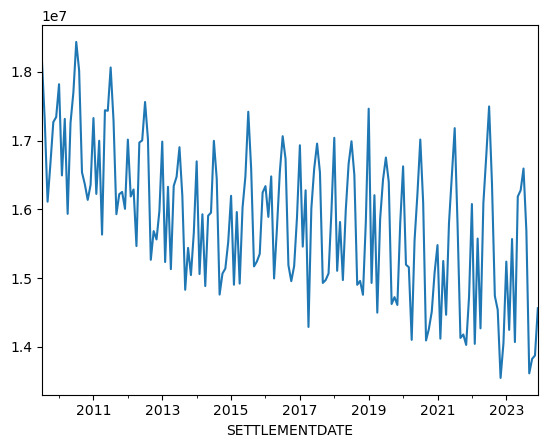

In [148]:
dem_hourly.sum(axis=1).resample("M").sum().plot()

Write

In [149]:
dem_hourly.to_csv(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/energy_demand/hourly_demand_20090701-20231230.csv"
)